In [12]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt

In [13]:
stocks = [
    "ADANIENT.NS",
    "ADANIPORTS.NS",
    "APOLLOHOSP.NS",
    "ASIANPAINT.NS",
    "AXISBANK.NS",
    "BAJAJ-AUTO.NS",
    "BAJFINANCE.NS",
    "BEL.NS",
    "BHARTIARTL.NS",
    "CIPLA.NS",
    "COALINDIA.NS",
    "DRREDDY.NS",
    "EICHERMOT.NS",
    "ETERNAL.NS",   # formerly Zomato
    "GRASIM.NS",
    "HCLTECH.NS",
    "HDFCBANK.NS",
    "HDFCLIFE.NS",
    "HEROMOTOCO.NS",
    "HINDALCO.NS",
    "HINDUNILVR.NS",
    "ICICIBANK.NS",
    "INDUSINDBK.NS",
    "INFY.NS",
    "ITC.NS",
    "JIOFIN.NS",
    "JSWSTEEL.NS",
    "KOTAKBANK.NS",
    "LT.NS",
    "M&M.NS",
    "MARUTI.NS",
    "NESTLEIND.NS",
    "NTPC.NS",
    "ONGC.NS",
    "POWERGRID.NS",
    "RELIANCE.NS",
    "SBILIFE.NS",
    "SBIN.NS",
    "SHRIRAMFIN.NS",
    "SUNPHARMA.NS",
    "TATACONSUM.NS",
    "TATAMOTORS.NS",
    "TATASTEEL.NS",
    "TCS.NS",
    "TECHM.NS",
    "TITAN.NS",
    "TRENT.NS",
    "ULTRACEMCO.NS",
    "WIPRO.NS"
]


start = "2020-01-01"

In [14]:
data = yf.download(
    stocks,
    start="2020-01-01",
    auto_adjust=True,
    progress=False
)["Close"]



HTTP Error 401: {"finance":{"result":null,"error":{"code":"Unauthorized","description":"Invalid Crumb"}}}
HTTP Error 401: {"finance":{"result":null,"error":{"code":"Unauthorized","description":"User is unable to access this feature - https://bit.ly/yahoo-finance-api-feedback"}}}

1 Failed download:
['TATAMOTORS.NS']: TypeError("argument of type 'NoneType' is not a container or iterable")


In [15]:
momentum = data.pct_change(63).shift(1)
returns = data.pct_change()

volatility = (
    returns
    .rolling(63)
    .std()
    .shift(1)
)

score = momentum / volatility

rebalance_dates = score.index[63::63]

In [16]:
portfolio_returns = []

for i in range(len(rebalance_dates)-1):

    current_date = rebalance_dates[i]
    next_date = rebalance_dates[i+1]

    ranking = score.loc[current_date].dropna()

    if len(ranking) < 5:
        continue

    top5 = ranking.nlargest(5).index

    period_returns = (
        returns.loc[current_date:next_date, top5]
        .mean(axis=1)
    )

    portfolio_returns.append(period_returns)

In [17]:
portfolio_returns = pd.concat(portfolio_returns)

portfolio_returns = portfolio_returns[
    ~portfolio_returns.index.duplicated()
]

portfolio_returns = portfolio_returns.dropna()

portfolio_returns.name = "Strategy"

In [18]:
equity_curve = (
    1 + portfolio_returns
).cumprod()

equity_curve.tail()

benchmark_returns = (
   data
    .pct_change()
    .mean(axis=1)
)

benchmark_returns = benchmark_returns.loc[
    equity_curve.index
]

benchmark_curve = (
    1 + benchmark_returns
).cumprod()

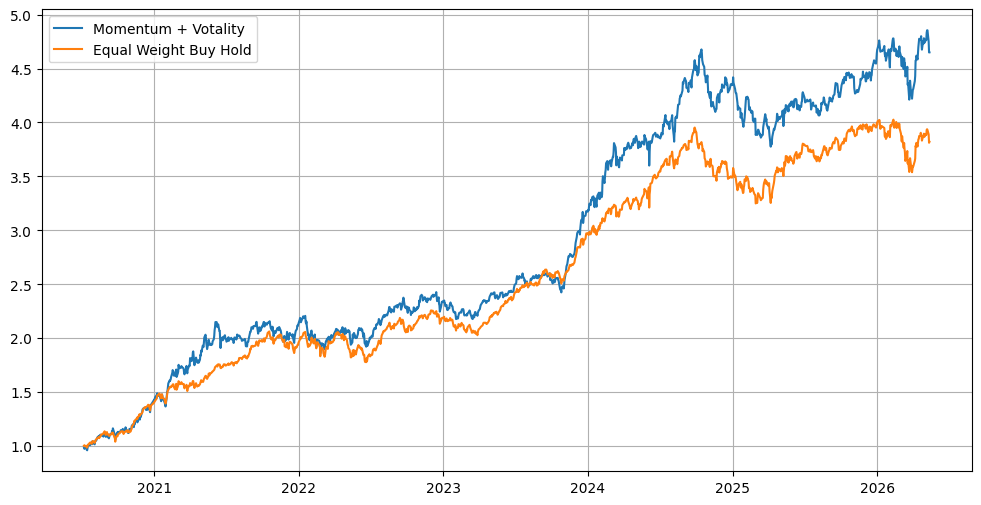

In [19]:
plt.figure(figsize=(12,6))

plt.plot(
    equity_curve,
    label="Momentum + Votality"
)

plt.plot(
    benchmark_curve,
    label="Equal Weight Buy Hold"
)

plt.legend()
plt.grid(True)
plt.show()

In [20]:

print(
    "Strategy Return:",
    round(
        (equity_curve.iloc[-1]-1)*100,
        2
    ),
    "%"
)

print(
    "Benchmark Return:",
    round(
        (benchmark_curve.iloc[-1]-1)*100,
        2
    ),
    "%"
)



years = (
    equity_curve.index[-1]
    -
    equity_curve.index[0]
).days / 365.25

cagr = (
    equity_curve.iloc[-1]
    ** (1 / years)
    - 1
)

print(f"CAGR: {cagr:.2%}")

sharpe = (
    portfolio_returns.mean()
    /
    portfolio_returns.std()
) * np.sqrt(252)

print(f"Sharpe: {sharpe:.2f}")

running_max = equity_curve.cummax()

drawdown = (
    equity_curve
    /
    running_max
    - 1
)

max_dd = drawdown.min()

print(f"Max Drawdown: {max_dd:.2%}")

Strategy Return: 365.01 %
Benchmark Return: 282.18 %
CAGR: 30.06%
Sharpe: 1.47
Max Drawdown: -19.28%
